<a href="https://colab.research.google.com/github/nimasha20020207/DL_Assignment_Y4S1/blob/main/IT23153486.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SE4050 – Deep Learning Assignment 2026

## Breast Cancer Classification Using a Pre-Activation Residual Neural Network (ResNet)


**Student Name:** Bhagya Navodyani  
**Student ID:** IT23153486
**Model:** Pre-Activation Residual Neural Network (ResNet)  

## 1. Imports and Libraries

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Other utilities
import random
import time

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


##2. Random Seed

In [5]:
# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


##3. Dataset upload

In [6]:
# Load the dataset
df = pd.read_csv('/content/Cancer_Data.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


Dataset Overview

The dataset is inspected to understand its structure, features, target variable, data types, class distribution, and missing values.

In [7]:
# Display the first five records
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
#Shape
# Check dataset dimensions
print("Dataset Shape:", df.shape)
print("Number of Samples:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (569, 33)
Number of Samples: 569
Number of Columns: 33


In [9]:
# Display all column names
print("Dataset Columns:")
for column in df.columns:
    print(column)

Dataset Columns:
id
diagnosis
radius_mean
texture_mean
perimeter_mean
area_mean
smoothness_mean
compactness_mean
concavity_mean
concave points_mean
symmetry_mean
fractal_dimension_mean
radius_se
texture_se
perimeter_se
area_se
smoothness_se
compactness_se
concavity_se
concave points_se
symmetry_se
fractal_dimension_se
radius_worst
texture_worst
perimeter_worst
area_worst
smoothness_worst
compactness_worst
concavity_worst
concave points_worst
symmetry_worst
fractal_dimension_worst
Unnamed: 32


In [10]:
# Check data types of each column
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [11]:
# Check class distribution of the target variable
print("Class Distribution:")
print(df['diagnosis'].value_counts())

print("\nClass Distribution (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (%):
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


##4. Missing values

In [12]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Unnamed: 32    569
dtype: int64


In [13]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 569


In [14]:
# Remove the completely empty column before EDA
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Cleaned dataset shape: (569, 32)
Remaining missing values: 0


Class-Distribution Graph

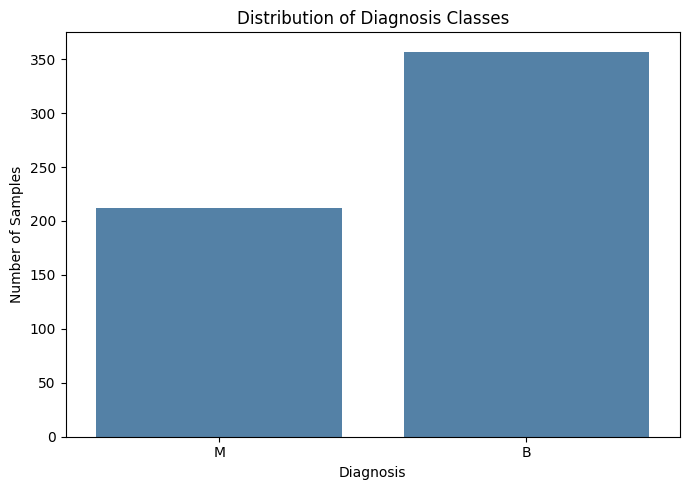

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='diagnosis',
    order=['M', 'B'],
    color='steelblue'
)

plt.title('Distribution of Diagnosis Classes')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

Correlation Heatmap

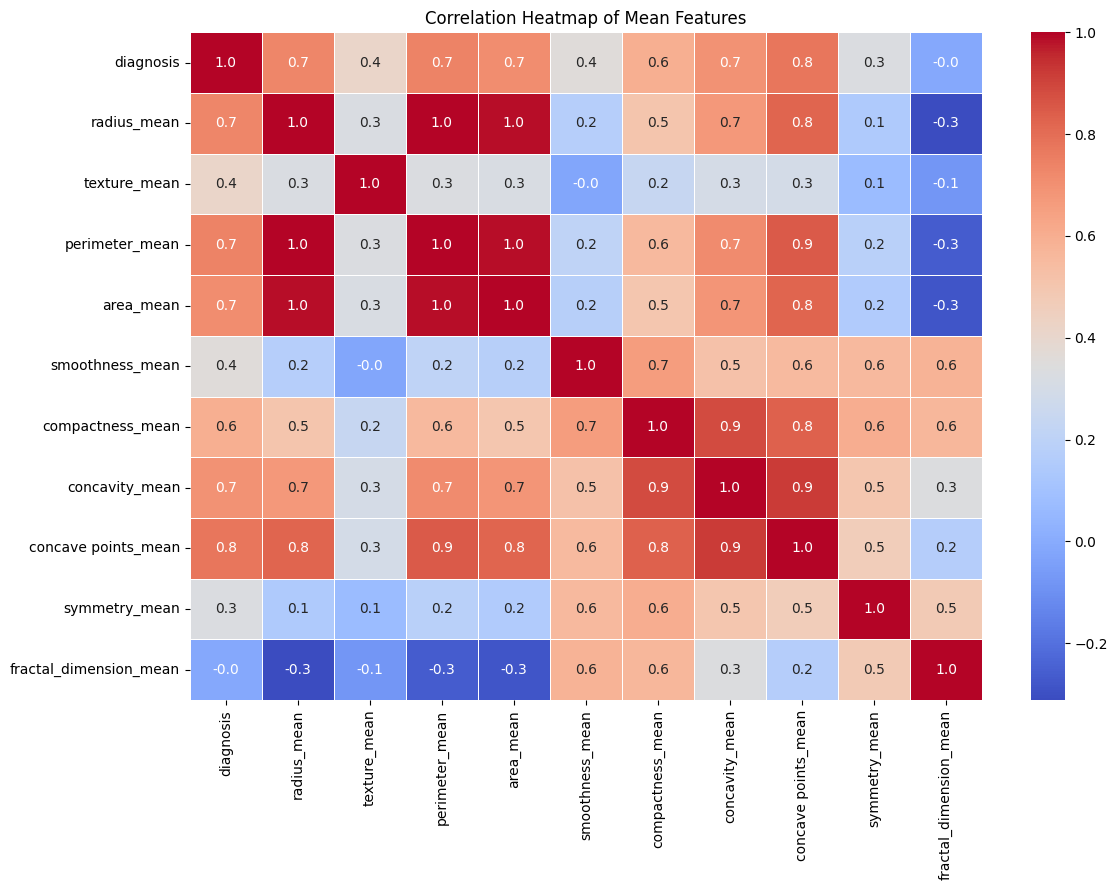

In [16]:
# Create a copy so that the original dataset is not changed
data_corr = df.copy()

# Encode diagnosis only for correlation analysis
data_corr['diagnosis'] = data_corr['diagnosis'].map({
    'M': 1,
    'B': 0
})

# Select diagnosis and mean features
mean_features = ['diagnosis'] + [
    column for column in data_corr.columns
    if column.endswith('_mean')
]

# Calculate correlation
corr_matrix = data_corr[mean_features].corr()

# Draw heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Mean Features')
plt.tight_layout()
plt.show()

Features and Target Separate

In [17]:
# Separate input features and target variable

# Remove ID because it is only a patient identifier
# Remove diagnosis because it is the target variable
X = df.drop(columns=['id', 'diagnosis'])

# Keep diagnosis as the target
y = df['diagnosis'].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of input features:", X.shape[1])

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Number of input features: 30


Target Encoding

In [18]:
# Encode the target variable
# Benign (B) = 0
# Malignant (M) = 1

y_encoded = y.map({'B': 0, 'M': 1})

print("Original target classes:")
print(y.value_counts())

print("\nEncoded target classes:")
print(y_encoded.value_counts())

print("\nUnique encoded values:", sorted(y_encoded.unique()))

Original target classes:
diagnosis
B    357
M    212
Name: count, dtype: int64

Encoded target classes:
diagnosis
0    357
1    212
Name: count, dtype: int64

Unique encoded values: [np.int64(0), np.int64(1)]


Validation Check

In [19]:
# Validate the prepared data before splitting

assert X.shape == (569, 30), "Unexpected feature matrix shape"
assert y_encoded.shape[0] == 569, "Unexpected target size"
assert X.isnull().sum().sum() == 0, "Missing values found in features"
assert y_encoded.isnull().sum() == 0, "Target encoding contains missing values"

print("Data preparation completed successfully.")
print("No missing values were found in the features or encoded target.")

Data preparation completed successfully.
No missing values were found in the features or encoded target.


## 5. Data Splitting and Standardization

The dataset is divided into training, validation, and test sets using stratified sampling. StandardScaler is fitted only on the training data to prevent data leakage.

In [20]:
# Split 15% as the final test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.15,
    random_state=SEED,
    stratify=y_encoded
)

# Split the remaining 85% into 70% training and 15% validation
validation_ratio = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=validation_ratio,
    random_state=SEED,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (397, 30) (397,)
Validation set: (86, 30) (86,)
Test set: (86, 30) (86,)


In [21]:
# Create the feature scaler
scaler = StandardScaler()

# Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using training statistics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining mean:", round(X_train_scaled.mean(), 4))
print("Training standard deviation:", round(X_train_scaled.std(), 4))
print("Model input dimension:", input_dim)

Scaled training shape: (397, 30)
Scaled validation shape: (86, 30)
Scaled test shape: (86, 30)

Training mean: -0.0
Training standard deviation: 1.0
Model input dimension: 30


In [22]:
assert X_train_scaled.shape == (397, 30)
assert X_val_scaled.shape == (86, 30)
assert X_test_scaled.shape == (86, 30)

assert not np.isnan(X_train_scaled).any()
assert not np.isnan(X_val_scaled).any()
assert not np.isnan(X_test_scaled).any()

print("Data splitting and standardization completed successfully.")

Data splitting and standardization completed successfully.


## 6. Pre-Activation Residual Block

A pre-activation residual block applies batch normalization and activation before each dense transformation. The shortcut connection allows the original information and gradients to flow directly through the network, which can improve the stability of deeper neural networks.

In [23]:
def preactivation_residual_block(
    x,
    units,
    dropout_rate=0.20,
    l2_rate=0.0001,
    block_name="ResidualBlock"
):
    """
    Create a pre-activation residual block for tabular data.

    Main path:
    BatchNorm -> ReLU -> Dense ->
    BatchNorm -> ReLU -> Dropout -> Dense

    Shortcut path:
    Identity or Dense projection

    Output:
    Main path + Shortcut path
    """

    # Preserve the input for the shortcut connection
    shortcut = x

    # Pre-activation before the first dense transformation
    residual = layers.BatchNormalization(
        name=f"{block_name}_bn1"
    )(x)

    residual = layers.Activation(
        'relu',
        name=f"{block_name}_relu1"
    )(residual)

    residual = layers.Dense(
        units,
        kernel_regularizer=regularizers.l2(l2_rate),
        name=f"{block_name}_dense1"
    )(residual)

    # Pre-activation before the second dense transformation
    residual = layers.BatchNormalization(
        name=f"{block_name}_bn2"
    )(residual)

    residual = layers.Activation(
        'relu',
        name=f"{block_name}_relu2"
    )(residual)

    residual = layers.Dropout(
        dropout_rate,
        name=f"{block_name}_dropout"
    )(residual)

    residual = layers.Dense(
        units,
        kernel_regularizer=regularizers.l2(l2_rate),
        name=f"{block_name}_dense2"
    )(residual)

    # Project the shortcut if its dimension differs
    if x.shape[-1] != units:
        shortcut = layers.Dense(
            units,
            use_bias=False,
            name=f"{block_name}_projection"
        )(shortcut)

    # Combine the residual and shortcut paths
    output = layers.Add(
        name=f"{block_name}_add"
    )([shortcut, residual])

    return output


print("Pre-activation residual block defined successfully.")

Pre-activation residual block defined successfully.


Block and Testing

In [24]:
# Verify the residual block using a temporary input

test_input = keras.Input(shape=(input_dim,), name="Test_Input")

test_output = preactivation_residual_block(
    test_input,
    units=64,
    dropout_rate=0.20,
    block_name="Test_Block"
)

test_block_model = keras.Model(
    inputs=test_input,
    outputs=test_output,
    name="Residual_Block_Test"
)

print("Input shape:", test_block_model.input_shape)
print("Output shape:", test_block_model.output_shape)

Input shape: (None, 30)
Output shape: (None, 64)


## 7. Pre-Activation ResNet Architecture

The model uses an initial feature-projection layer followed by three pre-activation residual blocks. Shortcut connections support gradient flow, while dropout and L2 regularization help reduce overfitting.

In [25]:
def create_preactivation_resnet(input_dim):
    """
    Create a Pre-Activation ResNet model
    for binary breast cancer classification.
    """

    # Input: 30 standardized numerical features
    inputs = keras.Input(
        shape=(input_dim,),
        name="Input_Features"
    )

    # Initial feature projection: 30 → 64
    x = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(0.0001),
        name="Initial_Projection"
    )(inputs)

    # Residual block 1: 64 → 64
    x = preactivation_residual_block(
        x,
        units=64,
        dropout_rate=0.20,
        l2_rate=0.0001,
        block_name="Block_1"
    )

    # Residual block 2: 64 → 64
    x = preactivation_residual_block(
        x,
        units=64,
        dropout_rate=0.20,
        l2_rate=0.0001,
        block_name="Block_2"
    )

    # Residual block 3: 64 → 32
    # A projection shortcut is created automatically
    x = preactivation_residual_block(
        x,
        units=32,
        dropout_rate=0.20,
        l2_rate=0.0001,
        block_name="Block_3"
    )

    # Final pre-activation classification head
    x = layers.BatchNormalization(
        name="Final_BatchNorm"
    )(x)

    x = layers.Activation(
        "relu",
        name="Final_ReLU"
    )(x)

    x = layers.Dropout(
        0.20,
        name="Final_Dropout"
    )(x)

    # Binary classification output
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="Diagnosis_Output"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="PreActivation_ResNet"
    )

    return model


print("Model architecture function defined successfully.")

Model architecture function defined successfully.


In [26]:
# Create the complete model

model = create_preactivation_resnet(input_dim)

print("Pre-Activation ResNet created successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Pre-Activation ResNet created successfully.
Model input shape: (None, 30)
Model output shape: (None, 1)


In [27]:
# Display the complete model architecture

model.summary()

Model: "PreActivation_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Features      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Initial_Projection  │ (None, 64)        │      1,984 │ Input_Features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_bn1         │ (None, 64)        │        256 │ Initial_Projecti… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_relu1       │ (None, 64)        │          0 │ Block_1_bn1[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_dense1      │ (None, 64)        │      4,160 │ Block_1_relu1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_bn2         │ (None, 64)        │        256 │ Block_1_dense1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_relu2       │ (None, 64)        │          0 │ Block_1_bn2[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_dropout     │ (None, 64)        │          0 │ Block_1_relu2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_dense2      │ (None, 64)        │      4,160 │ Block_1_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_1_add (Add)   │ (None, 64)        │          0 │ Initial_Projecti… │
│                     │                   │            │ Block_1_dense2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_bn1         │ (None, 64)        │        256 │ Block_1_add[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_relu1       │ (None, 64)        │          0 │ Block_2_bn1[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_dense1      │ (None, 64)        │      4,160 │ Block_2_relu1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_bn2         │ (None, 64)        │        256 │ Block_2_dense1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_relu2       │ (None, 64)        │          0 │ Block_2_bn2[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_dropout     │ (None, 64)        │          0 │ Block_2_relu2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Block_2_dense2      │ (None, 64)        │      4,160 │ Block_2_dropout[

 Total params: 25,377 (99.13 KB)

 Trainable params: 24,609 (96.13 KB)

 Non-trainable params: 768 (3.00 KB)

## 8. Model Compilation

The Pre-Activation ResNet is compiled using the Adam optimizer and binary cross-entropy loss. Accuracy, precision, recall, and ROC-AUC are monitored to provide a comprehensive evaluation of classification performance.

In [28]:
# Compile the Pre-Activation ResNet model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled successfully.")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss function: Binary Cross-Entropy")
print("Metrics: Accuracy, Precision, Recall, ROC-AUC")

Model compiled successfully.
Optimizer: Adam
Learning rate: 0.001
Loss function: Binary Cross-Entropy
Metrics: Accuracy, Precision, Recall, ROC-AUC


## 9. Training Callbacks

Early stopping is used to stop training when validation loss no longer improves and to restore the best-performing weights. ReduceLROnPlateau reduces the learning rate when the validation loss reaches a plateau.

In [29]:
# Configure training callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

print("Training callbacks configured successfully.")
print("EarlyStopping patience: 20 epochs")
print("ReduceLROnPlateau patience: 7 epochs")

Training callbacks configured successfully.
EarlyStopping patience: 20 epochs
ReduceLROnPlateau patience: 7 epochs


## 10. Model Training

The Pre-Activation ResNet is trained using the standardized training dataset and evaluated against the validation dataset after each epoch. Early stopping and learning-rate reduction are applied to improve generalization and training stability.

In [30]:
# Train the Pre-Activation ResNet
start_time = time.time()

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\nModel training completed.")
print(f"Epochs completed: {len(history.history['loss'])}")
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8539 - auc: 0.9190 - loss: 0.4613 - precision: 0.8000 - recall: 0.8108 - val_accuracy: 0.9651 - val_auc: 0.9931 - val_loss: 0.2635 - val_precision: 0.9394 - val_recall: 0.9688 - learning_rate: 0.0010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9395 - auc: 0.9744 - loss: 0.2982 - precision: 0.9247 - recall: 0.9122 - val_accuracy: 0.9767 - val_auc: 0.9954 - val_loss: 0.2035 - val_precision: 0.9412 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9496 - auc: 0.9815 - loss: 0.2497 - precision: 0.9324 - recall: 0.9324 - val_accuracy: 0.9767 - val_auc: 0.9971 - val_loss: 0.1855 - val_precision: 0.9412 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9521 - auc: 0.9840 - loss: 0.2252 - precision: 0.9388 - recall: 0.9324 - val_accuracy: 0.9767 - val_auc: 0.9988 - val_loss: 0.1751 - val

## 11. Training and Validation Performance

The training history is visualized using loss and accuracy curves. These graphs help evaluate convergence and identify possible overfitting or underfitting.

Best epoch based on validation loss: 18
Best validation loss: 0.1081
Validation accuracy at best epoch: 0.9884


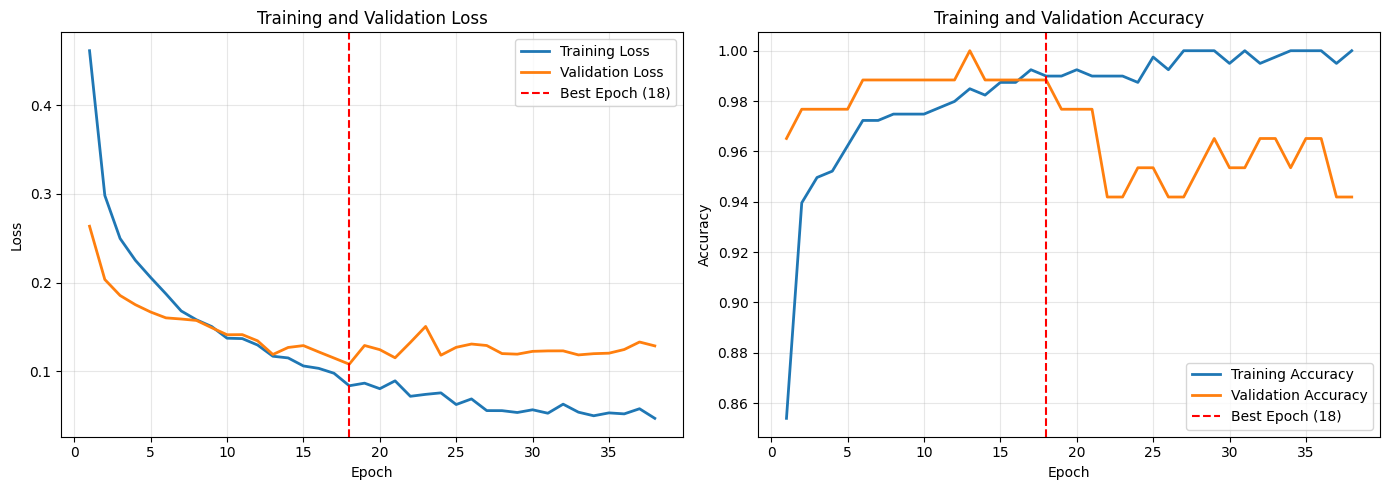

In [31]:
# Identify the epoch with the lowest validation loss
best_epoch = np.argmin(history.history['val_loss']) + 1

print("Best epoch based on validation loss:", best_epoch)
print(
    "Best validation loss:",
    f"{history.history['val_loss'][best_epoch - 1]:.4f}"
)
print(
    "Validation accuracy at best epoch:",
    f"{history.history['val_accuracy'][best_epoch - 1]:.4f}"
)

# Create training and validation graphs
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)
plt.plot(
    epochs_range,
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)
plt.axvline(
    best_epoch,
    color='red',
    linestyle='--',
    label=f'Best Epoch ({best_epoch})'
)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)
plt.plot(
    epochs_range,
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)
plt.axvline(
    best_epoch,
    color='red',
    linestyle='--',
    label=f'Best Epoch ({best_epoch})'
)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()